In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content


drive  sample_data


In [ ]:
!find /content/drive -name "data.yaml"

/content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/data.yaml


In [ ]:
!nvidia-smi

Sat Jun 13 18:29:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics
!ls "/content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8"

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [12]:


from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data="/content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    project="ISRO_Mars",
    name="Mars_Features_v1"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=F

In [15]:
!ls /content/runs/detect/ISRO_Mars/Mars_Features_v1/weights

best.pt  last.pt


In [16]:
!cp "/content/runs/detect/ISRO_Mars/Mars_Features_v1/weights/best.pt" \
"/content/drive/MyDrive/ISRO_YOLO/"

In [17]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/ISRO_Mars/Mars_Features_v1/weights/best.pt")

metrics = model.val(
    data="/content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/data.yaml",
    split="test"
)

print(metrics)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.9±1.3 MB/s, size: 110.4 KB)
val: Scanning /content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/test/labels... 116 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 116/116 2.5it/s 45.5s
val: New cache created: /content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.8it/s 4.5s
                   all        116        116      0.983      0.991      0.995       0.96
                 crack         24         24      0.993          1      0.995      0.989
                crater         23         23      0.993          1      0.995      0.988
          layered_rock         22         22      0.946          1      0.995      0.991
   

In [18]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/ISRO_Mars/Mars_Features_v1/weights/best.pt")

results = model.predict(
    source="/content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/test/images",
    save=True,
    conf=0.25
)


image 1/116 /content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/test/images/IMG_20260609_125213559_jpg.rf.b4ce733c04bc2adc3a7e17e0e53c02f1.jpg: 640x640 1 layered_rock, 1 rocks, 16.1ms
image 2/116 /content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/test/images/IMG_20260609_125252077_HDR_jpg.rf.5b1b0b1f4defa5b22db906ab689679a5.jpg: 640x640 1 rocks, 39.7ms
image 3/116 /content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/test/images/IMG_20260609_125357025_HDR_jpg.rf.db61b87a5c84759af9b21cd3b71a39d4.jpg: 640x640 1 rocks, 16.2ms
image 4/116 /content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/test/images/IMG_20260609_125423204_HDR_jpg.rf.0bd67380f29258b3e8cef73eb783e4e7.jpg: 640x640 1 rocks, 16.1ms
image 5/116 /content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/test/images/IMG_20260609_125617517_HDR_jpg.rf.fe635b0561ceb515b62258af7fd984af.jpg: 640x640 1 rocks, 16.1ms
image 6/116 /content/drive/MyDrive/ISRO_YOLO/My First Project.v1i.yolov8/test/imag

In [19]:
import os

pred_dir = "/content/runs/detect/predict"

print(os.listdir(pred_dir)[:10])

['IMG_20260609_153051609_jpg.rf.a52419bf28641361c18261d90bb7295e.jpg', 'IMG_20260611_171719346_HDR_jpg.rf.354333b53d19b0c043da269dafc558e9.jpg', 'IMG_20260609_151250363_HDR_jpg.rf.e65aa77ada5bf71878dcb025fce4584a.jpg', 'IMG_20260609_172458997_jpg.rf.0fc8d701132bde5413738637431c70c5.jpg', 'IMG_20260611_171810025_jpg.rf.1ea2f5f28591e1e855d91a741ba8a802.jpg', 'IMG_20260609_130210075_HDR_jpg.rf.3477dc8c8622e401a3330362939a895a.jpg', 'IMG_20260609_165401355_jpg.rf.4dd472dd441ec7720f95d7c6bf75345e.jpg', 'IMG_20260609_132335499_HDR_jpg.rf.2ed1f73ae6a0106f27e6cf4f104e5be6.jpg', 'IMG_20260611_172033693_jpg.rf.8f98833a7063080fc54a56b36bca1216.jpg', 'IMG_20260609_165328985_HDR_jpg.rf.847caf1c7813ed11c0f8ce7fd8c6c42d.jpg']


/content/runs/detect
/content/runs/detect/predict
/content/runs/detect/val
/content/runs/detect/ISRO_Mars
/content/runs/detect/ISRO_Mars/Mars_Features_v1
/content/runs/detect/ISRO_Mars/Mars_Features_v1/weights
['IMG_20260609_153051609_jpg.rf.a52419bf28641361c18261d90bb7295e.jpg', 'IMG_20260611_171719346_HDR_jpg.rf.354333b53d19b0c043da269dafc558e9.jpg', 'IMG_20260609_151250363_HDR_jpg.rf.e65aa77ada5bf71878dcb025fce4584a.jpg', 'IMG_20260609_172458997_jpg.rf.0fc8d701132bde5413738637431c70c5.jpg', 'IMG_20260611_171810025_jpg.rf.1ea2f5f28591e1e855d91a741ba8a802.jpg']


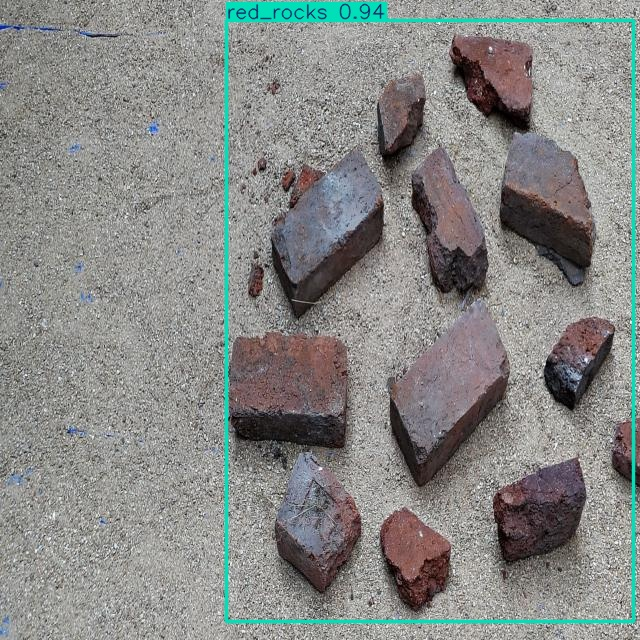

In [23]:
!find /content/runs/detect -type d
import os

pred_dir = "/content/runs/detect/predict"   # change if predict2/predict3 exists

print(os.listdir(pred_dir)[:5])
from PIL import Image
from IPython.display import display

pred_dir = "/content/runs/detect/predict"

img_name = os.listdir(pred_dir)[0]

img = Image.open(os.path.join(pred_dir, img_name))

display(img)